## 0. Imports & Chargement

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
import time
import warnings
import arabic_reshaper
from bidi.algorithm import get_display
import arabic_reshaper
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'  
warnings.filterwarnings('ignore')

from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import sys
sys.path.append('../src/models')
from lstm_model import build_lstm_model

PROCESSED_PATH = '../data/processed/'
RESULTS_PATH   = '../results/scores/'
FIGURES_PATH   = '../results/figures/'
os.makedirs(RESULTS_PATH, exist_ok=True)

with open(PROCESSED_PATH + 'ds2_params.json') as f:
    params = json.load(f)

VOCAB_SIZE  = params['vocab_size']
MAXLEN      = params['maxlen']
NUM_CLASSES = params['num_classes']

X_train = np.load(PROCESSED_PATH + 'X_train_pad_ds2.npy')
X_val   = np.load(PROCESSED_PATH + 'X_val_pad_ds2.npy')
X_test  = np.load(PROCESSED_PATH + 'X_test_pad_ds2.npy')
y_train = np.load(PROCESSED_PATH + 'y_train_ds2.npy')
y_val   = np.load(PROCESSED_PATH + 'y_val_ds2.npy')
y_test  = np.load(PROCESSED_PATH + 'y_test_ds2.npy')

with open(PROCESSED_PATH + 'tfidf_vectorizer_ds2.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open(PROCESSED_PATH + 'keras_tokenizer_ds2.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

df = pd.read_csv(PROCESSED_PATH + 'ds2_preprocessed.csv')

print(f'Données chargées ✅')
print(f'X_train : {X_train.shape}')
print(f'TF-IDF vocab : {len(tfidf.vocabulary_)}')

Données chargées ✅
X_train : (6035, 24)
TF-IDF vocab : 10000


## 1. Calcul des Scores MI

In [25]:
# Recalculer TF-IDF sur le train seulement
df_train = df.iloc[:len(y_train)]
X_tfidf_train = tfidf.transform(df_train['text_clean'])

# Calculer les scores MI
print('Calcul des scores MI...')
mi_scores = mutual_info_classif(X_tfidf_train, y_train, random_state=42)

# Créer un DataFrame des scores
vocab = tfidf.get_feature_names_out()
mi_df = pd.DataFrame({'mot': vocab, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False).reset_index(drop=True)

print(f'Top 10 mots les plus informatifs :')
print(mi_df.head(10).to_string(index=False))

Calcul des scores MI...
Top 10 mots les plus informatifs :
   mot  mi_score
  الله  0.069911
    لا  0.052863
    ما  0.052654
 اللهم  0.030759
  اللي  0.026897
 والله  0.020285
 الخير  0.018794
  يارب  0.017953
   يوم  0.016772
الهلال  0.015937


## Bloc 2 — Visualisation Top 50 Mots MI

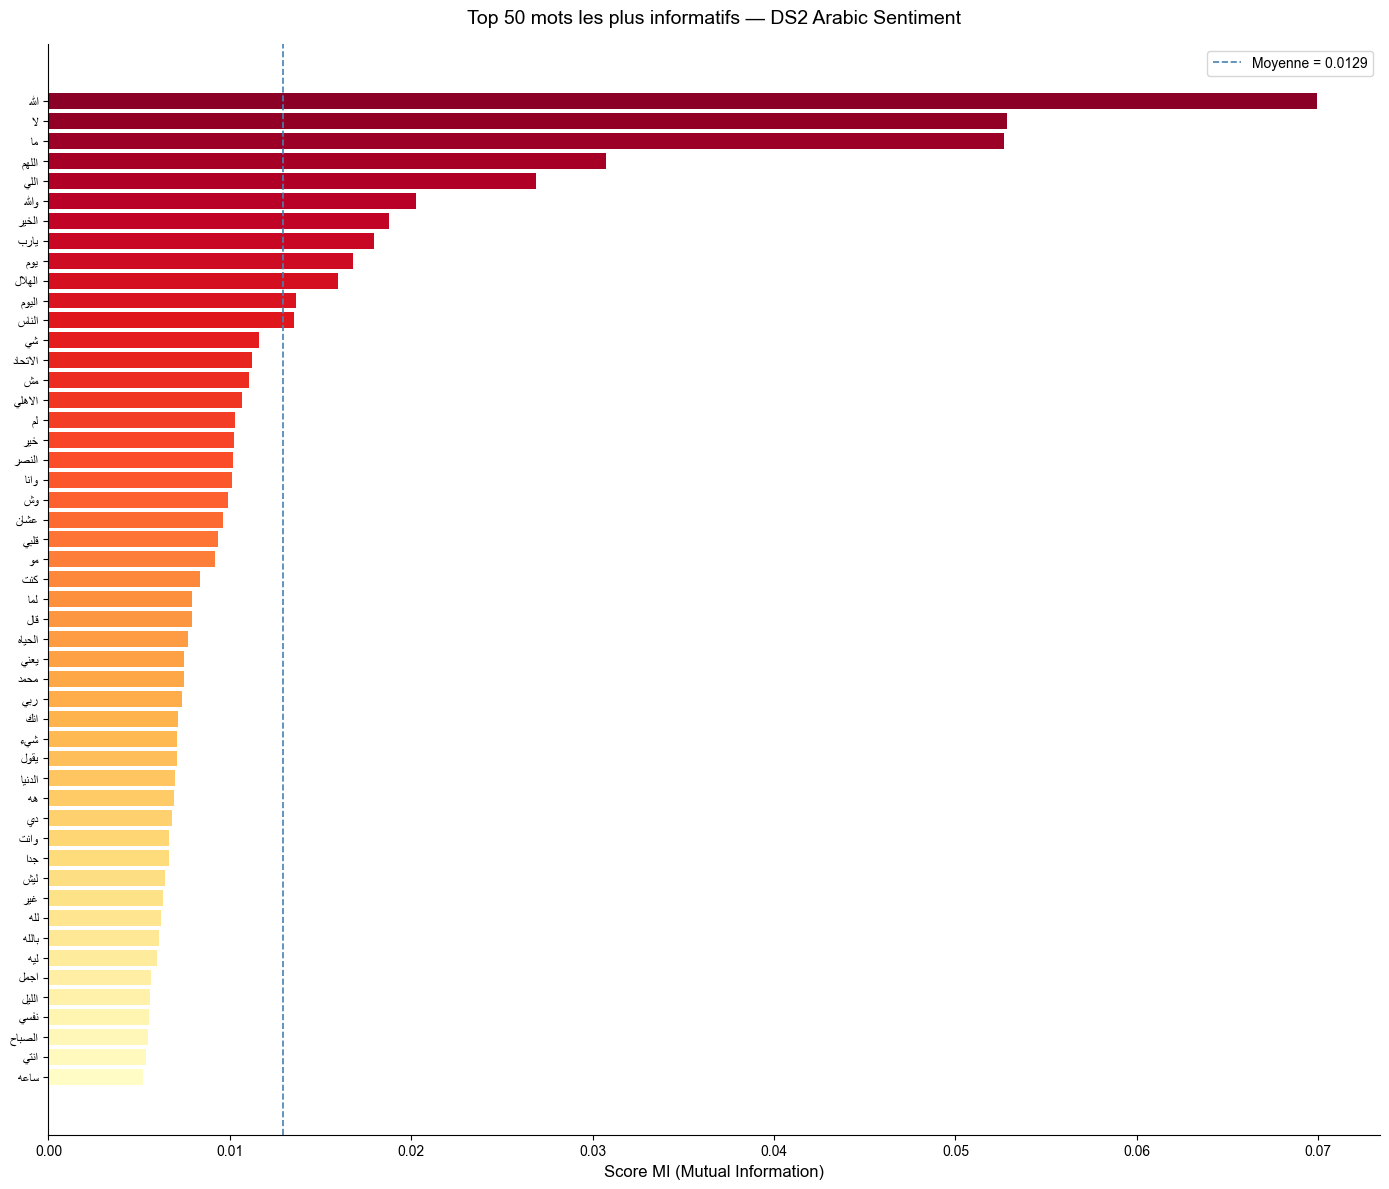

In [26]:

top50 = mi_df.head(50).copy()

top50['mot_display'] = top50['mot'].apply(
    lambda w: get_display(arabic_reshaper.reshape(w))
)

fig, ax = plt.subplots(figsize=(14, 12))
palette = sns.color_palette("YlOrRd", n_colors=50)[::-1]

ax.barh(range(50), top50['mi_score'].values, color=palette)
ax.set_yticks(range(50))
ax.set_yticklabels(top50['mot_display'].values, fontsize=9, fontfamily='Arial')
ax.invert_yaxis()
ax.set_xlabel('Score MI (Mutual Information)', fontsize=12)
ax.set_title('Top 50 mots les plus informatifs — DS2 Arabic Sentiment', fontsize=14, pad=15)
ax.axvline(x=top50['mi_score'].mean(), color='steelblue',
           linestyle='--', linewidth=1.2,
           label=f"Moyenne = {top50['mi_score'].mean():.4f}")
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'mi_top50_ds2.png', dpi=150, bbox_inches='tight')
plt.show()


## Helper — Fonctions MI remapping

In [27]:
def build_mi_sequences(k, mi_df, tokenizer, X_train, X_val, X_test):
    top_k_words = mi_df.head(k)['mot'].tolist()
    
    
    new_vocab = {word: idx+1 for idx, word in enumerate(top_k_words)}
    
    old_to_new = {}
    for word, new_idx in new_vocab.items():
        old_idx = tokenizer.word_index.get(word)
        if old_idx is not None:
            old_to_new[old_idx] = new_idx
    
    print(f"k={k} | mots remappés : {len(old_to_new)}/{k}")
    
    def remap(X):
        X_new = np.zeros_like(X)
        for old_idx, new_idx in old_to_new.items():
            X_new[X == old_idx] = new_idx
        return X_new
    
    return remap(X_train), remap(X_val), remap(X_test), len(old_to_new)+1


def train_mi_remapped(k, mi_df, tokenizer, X_train, X_val, X_test,
                      y_train, y_val, y_test):
    
    Xtr, Xvl, Xts, new_vocab_size = build_mi_sequences(
        k, mi_df, tokenizer, X_train, X_val, X_test
    )
    
    model = build_lstm_model(
        vocab_size=new_vocab_size,
        maxlen=MAXLEN,
        n_classes=NUM_CLASSES
    )
    
    es = EarlyStopping(monitor='val_loss', patience=3,
                       restore_best_weights=True, verbose=1)
    
    t0 = time.time()
    history = model.fit(
        Xtr, y_train,
        validation_data=(Xvl, y_val),
        epochs=20,
        batch_size=64,
        callbacks=[es],
        verbose=1
    )
    elapsed = round(time.time() - t0, 1)
    
    y_pred = np.argmax(model.predict(Xts, verbose=0), axis=1)
    
    results = {
        'method'   : f'MI k={k}',
        'features' : k,
        'accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'f1_macro' : round(f1_score(y_test, y_pred, average='macro'), 4),
        'precision': round(precision_score(y_test, y_pred, average='macro'), 4),
        'recall'   : round(recall_score(y_test, y_pred, average='macro'), 4),
        'time_s'   : elapsed
    }
    
    for key, val in results.items():
        print(f"{key:<12} : {val}")
    
    return results, history, model



## Bloc 3 — LSTM avec MI k=300

In [28]:
results_300, history_300, model_300 = train_mi_remapped(
    300, mi_df, tokenizer, X_train, X_val, X_test, y_train, y_val, y_test
)

k=300 | mots remappés : 300/300
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.5032 - loss: 0.6936 - val_accuracy: 0.5073 - val_loss: 0.6954
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5249 - loss: 0.6918 - val_accuracy: 0.5770 - val_loss: 0.6799
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5360 - loss: 0.6877 - val_accuracy: 0.5336 - val_loss: 0.6898
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5877 - loss: 0.6660 - val_accuracy: 0.5847 - val_loss: 0.6843
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6204 - loss: 0.6534 - val_accuracy: 0.5986 - val_loss: 0.6800
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
method       : MI k=300
features     : 300
accuracy     : 0.5641
f1_macro     : 0.4998
precision    : 0.6157
recall       : 0.5587
time_s       : 15.2


## Bloc 4 — LSTM avec MI k=700

In [29]:
results_700, history_700, model_700 = train_mi_remapped(
    700, mi_df, tokenizer, X_train, X_val, X_test, y_train, y_val, y_test
)

k=700 | mots remappés : 700/700
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.5024 - loss: 0.6936 - val_accuracy: 0.4927 - val_loss: 0.6931
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5534 - loss: 0.6808 - val_accuracy: 0.5623 - val_loss: 0.6877
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6250 - loss: 0.6515 - val_accuracy: 0.5986 - val_loss: 0.6749
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6449 - loss: 0.6355 - val_accuracy: 0.6025 - val_loss: 0.6670
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6724 - loss: 0.6144 - val_accuracy: 0.5916 - val_loss: 0.6780
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6814 - loss: 0.6054 - val_accuracy: 0.6040 - val_loss: 0.6781
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6883 - loss: 0.6026 - val_accuracy: 0.5978 - val_loss: 0.6923
Epoch 7: early stopping
Restoring model weights from the end of the best epoch:

## Bloc 5 — LSTM avec MI k=1500

In [30]:
results_1500, history_1500, model_1500 = train_mi_remapped(
    1500, mi_df, tokenizer, X_train, X_val, X_test, y_train, y_val, y_test
)

k=1500 | mots remappés : 1500/1500
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.5135 - loss: 0.6939 - val_accuracy: 0.5073 - val_loss: 0.6944
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5112 - loss: 0.6931 - val_accuracy: 0.4927 - val_loss: 0.6924
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5950 - loss: 0.6640 - val_accuracy: 0.5955 - val_loss: 0.6685
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6669 - loss: 0.6188 - val_accuracy: 0.6187 - val_loss: 0.6992
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7001 - loss: 0.5837 - val_accuracy: 0.6203 - val_loss: 0.6738
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7203 - loss: 0.5567 - val_accuracy: 0.6048 - val_loss: 0.6785
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
method       : MI k=1500
features     : 1500
accuracy     : 0.5989
f1_macro     : 0.5549
precision    : 0.651
recall   

## Bloc 6 — Comparaison des résultats MI

   method  features  accuracy  f1_macro  precision  recall  time_s
 Baseline     10000    0.6337    0.6240     0.6449  0.6314    19.9
 MI k=300       300    0.5641    0.4998     0.6157  0.5587    15.2
 MI k=700       700    0.6167    0.6030     0.6304  0.6140    19.9
MI k=1500      1500    0.5989    0.5549     0.6510  0.5942    25.4


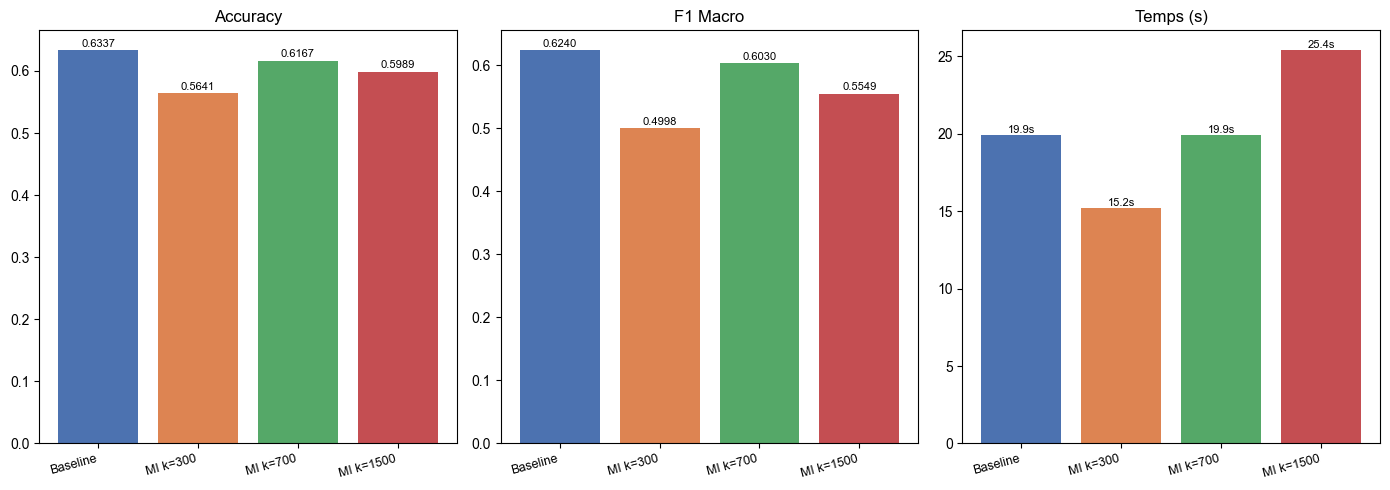

In [31]:
baseline_row = {
    'method'   : 'Baseline',
    'features' : 10000,
    'accuracy' : 0.6337,
    'f1_macro' : 0.6240,
    'precision': 0.6449,
    'recall'   : 0.6314,
    'time_s'   : 19.9
}

all_results = pd.DataFrame([baseline_row, results_300, results_700, results_1500])
print(all_results.to_string(index=False))
all_results.to_csv(RESULTS_PATH + 'mi_comparison_ds2.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['accuracy', 'f1_macro', 'time_s']
titles  = ['Accuracy', 'F1 Macro', 'Temps (s)']
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(all_results['method'], all_results[metric], color=colors)
    ax.set_title(title)
    ax.set_xticklabels(all_results['method'], rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, all_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{val:.4f}' if metric != 'time_s' else f'{val:.1f}s',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'mi_comparison_ds2.png', dpi=150, bbox_inches='tight')
plt.show()

## Bloc 7 — Interprétation

### Résultats MI Feature Selection — DS2 Arabic Sentiment

| Méthode | Features | Accuracy | F1 Macro | Temps |
|---------|----------|----------|----------|-------|
| Baseline | 10 000 | 0.6337 | 0.6240 | 19.9s |
| MI k=300 | 300 | 0.5641 | 0.4998 | 15.2s |
| MI k=700 | 700 | 0.6167 | 0.6030 | 19.9s |
| MI k=1500 | 1500 | 0.5989 | 0.5549 | 25.4s |

---

### Analyse des résultats

**Le Baseline reste le meilleur** sur accuracy (0.6337) et F1 macro (0.6240).
Aucune valeur de k ne réussit à le dépasser.

**k=700 est le meilleur parmi les MI** avec accuracy=0.6167 et F1=0.6030, très proche du baseline.

**k=300 est le pire** : trop peu de mots, le LSTM n'a pas assez d'information pour apprendre, F1 tombe à 0.4998 (presque aléatoire).

**k=1500 moins bon que k=700** : surprenant, mais le LSTM avec un vocabulaire plus grand prend plus de temps à converger et l'Early Stopping l'arrête trop tôt (25.4s, plus lent).

---

### Pourquoi MI ne bat pas le Baseline ?

La MI sélectionne les mots selon leur score **TF-IDF individuel**, sans tenir compte de l'ordre des mots. Mais le LSTM est un modèle **séquentiel** — l'ordre des mots compte. En réduisant le vocabulaire, on perd des mots qui sont peut-être peu informatifs seuls, mais importants dans leur contexte séquentiel.

Exemple : le mot **يوم** (jour) a un score MI modeste, mais dans la séquence "يوم سعيد" (bonne journée) il est crucial pour le sentiment positif.

---

### Overfitting

Le problème d'overfitting du Baseline (Train 89% vs Val 60%) **persiste avec MI**. La réduction de vocabulaire ne suffit pas à régulariser le modèle. La sélection MI agit sur les features TF-IDF, pas directement sur la capacité du LSTM.

---

### Perspectives — Sprint 5 (Algorithme Génétique)

L'Algorithme Génétique va chercher directement **la combinaison optimale de features** en maximisant la performance du LSTM. Contrairement à MI qui classe les mots indépendamment, le GA teste des **sous-ensembles entiers** — ce qui est théoriquement plus adapté à un modèle séquentiel.